# 03: Accessibility Analysis

## 1. Introduction

### What "accessibility" means here

This notebook computes physical accessibility to healthcare and education
facilities for every settled grid cell in both study areas making use of the network travel time which is how long it actually takes to reach the nearest facility by
following the real road network, since roads rarely run in straight lines
and a facility that's close in a straight line might be effectively far
away if there's no direct road connecting to it.

### Why three transport modes, not one

| Mode | Assumed speed | Notes |
|---|---|---|
| **Walk** | 5 km/h | OSM's "walk" road network |
| **Okada** (motorcycle taxi) | 25 km/h | OSM's "drive" road network, lower assumed speed |
| **Drive** (private/shared vehicle) | 35 km/h | OSM's "drive" road network |

Modeling all three matters because walking-only access analysis which is the
default in most similar studies understates real accessibility in a
context like Akure, where okada is how most people actually reach a clinic
or school beyond a short radius. A 30-minute budget covers very different
ground on foot vs. by okada vs. by car, so **each mode uses its own
access-deficit threshold** rather than one blanket cutoff.*italicized text*

### Method summary

For each settled grid cell (from Notebook 02) and each mode:
1. Build a routable network graph for that mode.
2. Compute network distance (km) and travel time (minutes) to the nearest
   health facility and nearest school.
3. Flag the cell as underserved for a service if travel time exceeds that
   mode's threshold.
4. Combine both service flags into a 0–2 composite access-deficit score.

### Key GIS/network-analysis concept: what is a "routable graph"?

A road network becomes "routable" when it's represented as a graph:
intersections and dead-ends become **nodes**, road segments between them
become **edges**, and each edge carries a weight (here, travel time in
minutes, derived from its real-world length and the mode's assumed speed).
Finding the "fastest route" between two points then becomes a shortest-
path search over this graph, this is the same underlying idea used by any
turn-by-turn navigation app, just built here directly from OSM's road
tags via the `OSMnx` library rather than a commercial routing service.

### A performance note worth understanding, not just trusting

Naively, computing "nearest facility" for *every* grid cell would mean
running a separate shortest-path search from each cell to *every*
facility, then keeping the minimum. For hundreds of cells and dozens of
facilities, that's thousands of searches per mode which  couold be take up to  an hour to run. The fix used here (`batch_nearest_facility_distances`, in
`akure_access.accessibility.isochrones`) instead runs a **single**
multi-source shortest-path search *from all facilities at once*, which
finds the nearest-facility distance to *every* node in the graph in one
pass, so each grid cell's answer is just a fast lookup.

### Expected outputs

For each study area, the grid enriched with per-mode travel times and
access-deficit scores (see Section 7).

### Prerequisites

- Notebooks 01 and 02 have been run for both study areas.
- This notebook makes live OSM network queries per mode per LGA (via
  OSMnx) — expect noticeably longer runtime than Notebooks 01–02,
  especially for the "drive" network in denser urban areas.

## 2. Imports

This notebook imports `resolve_boundary` from `lga_extractor` (to
constrain the OSM road-network query to this LGA's area) and three
functions from `akure_access.accessibility`: `add_access_times` (the
network-routing step), `add_access_deficit_score` (converts travel times
into the 0–2 composite score), and `sanitize_for_export` (converts
internal `inf` sentinel values — used to represent "unreachable" — into
`NaN` for clean GeoJSON export).

### 2.1 Environment setup

Same Colab/local detection pattern as Notebooks 01–02.

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
DASHBOARD_DRIVE_FOLDER = "Akure Access Dashboard"
EXTRACTOR_DRIVE_FOLDER = "LGA OSM Extractor"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DASHBOARD_DIR = f"/content/drive/MyDrive/{DASHBOARD_DRIVE_FOLDER}"
    EXTRACTOR_DIR = f"/content/drive/MyDrive/{EXTRACTOR_DRIVE_FOLDER}"

    if not os.path.exists(DASHBOARD_DIR):
        raise FileNotFoundError(f"Expected '{DASHBOARD_DIR}' in your Google Drive.")

    %cd {DASHBOARD_DIR}/notebooks
    !pip install osmnx geopandas shapely fiona networkx pandas numpy leafmap --quiet

    # Add the dashboard repo root to sys.path (unconditionally) so the
    # `src` package is importable regardless of relative-path quirks
    # after %cd, then add the extractor repo path if it's available.
    sys.path.append(DASHBOARD_DIR)
    if os.path.exists(EXTRACTOR_DIR):
        sys.path.append(EXTRACTOR_DIR)
    else:
        print(
            f"Warning: '{EXTRACTOR_DIR}' not found in Drive. The "
            f"lga_extractor import (used in Notebook 01, and for boundary "
            f"resolution here) will fail unless it's installed another way."
        )

    print(f"Running in Colab. Working directory: {os.getcwd()}")
else:
    sys.path.append("..")
    sys.path.append("../../lga-osm-extractor")
    print("Running locally.")


Mounted at /content/drive
/content/drive/MyDrive/Akure Access Dashboard/notebooks
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.1/669.1 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.

### 2.2 Package imports

In [2]:
import geopandas as gpd
from lga_extractor import resolve_boundary
from akure_access.accessibility import (
    add_access_times,
    add_access_deficit_score,
    sanitize_for_export,
    graph_from_roads,
    build_isochrones_for_facilities,
)

## 3. Configuration

### 3.1 Why each mode gets its own threshold?

Mode-specific access thresholds are set here. The walking threshold
(30 min) follows common accessibility-literature conventions; the okada
and drive thresholds are set tighter *in time* but represent a *larger*
effective service area, since these modes cover more ground per minute,
a 15-minute drive covers roughly the same ground as a much longer walk, so
using the same time cutoff for both would misrepresent effective access
for faster modes.

In [3]:
STUDY_AREAS = [
    {"lga_name": "Akure North", "state_name": "Ondo", "data_dir": "../data/processed/akure_north"},
    {"lga_name": "Akure South", "state_name": "Ondo", "data_dir": "../data/processed/akure_south"},
]

MODES = ("walk", "okada", "drive")

ACCESS_THRESHOLDS_MIN = {
    "walk": 30,
    "okada": 20,
    "drive": 15,
}

print("Modes and thresholds:")
for mode, threshold in ACCESS_THRESHOLDS_MIN.items():
    print(f"  {mode:<6} -> underserved if > {threshold} min")


Modes and thresholds:
  walk   -> underserved if > 30 min
  okada  -> underserved if > 20 min
  drive  -> underserved if > 15 min


## 4. Data Loading

For each study area, this notebook loads the grid produced by Notebook 02
(already carrying `building_count` and completeness flags), plus the raw
roads/health/schools layers from Notebook 01 needed to build the routable
network and locate facilities. It also re-resolves the LGA boundary, used
to constrain the OSMnx network query to this LGA's extent rather than
pulling in a much larger surrounding road network.

This loading step is folded into Section 5's processing loop (rather than
a separate cell) since each study area's load-then-score sequence is a
single logical unit — see that section for the actual `gpd.read_file()`
calls.

## 5. Processing

### 5.1 Accessibility scoring (both study areas, all three modes)

For each LGA, this loads the completeness grid from Notebook 02, builds a
network graph per mode, computes nearest-facility distance and time for
health and education access, and derives a per-mode access-deficit score.

This is the most computationally intensive step in the pipeline; the
cell below reports progress per LGA/mode so you can monitor it.

**Important implementation detail on `inf` handling:** unreachable cells
are represented internally as `inf` (infinite travel time) precisely
*because* `add_access_deficit_score()` needs to recognize them as
maximally underserved. `sanitize_for_export()` — which converts these
`inf` values into `NaN` for clean file export — is deliberately called
**only after** all mode scoring is complete. Calling it earlier would
silently break the deficit-scoring logic (an earlier version of this
pipeline made exactly this mistake; two regression tests in
`tests/test_scoring.py` now lock in the correct ordering).

In [4]:
scored_results = {}

for area in STUDY_AREAS:
    lga_name, data_dir = area["lga_name"], area["data_dir"]
    print(f"=== {lga_name} ===")

    grid = gpd.read_file(f"{data_dir}/grid_completeness.geojson")
    roads = gpd.read_file(f"{data_dir}/roads.geojson")
    health = gpd.read_file(f"{data_dir}/health_facilities.geojson")
    schools = gpd.read_file(f"{data_dir}/schools.geojson")

    boundary = resolve_boundary(lga_name=lga_name, state_name=area["state_name"])
    boundary_polygon_wgs84 = boundary.geometry.iloc[0]

    print(f"  Computing access times for modes: {MODES}...")
    grid = add_access_times(
        grid, roads, health, schools,
        boundary_polygon_wgs84=boundary_polygon_wgs84,
        modes=MODES,
    )

    for mode in MODES:
        grid = add_access_deficit_score(grid, threshold_min=ACCESS_THRESHOLDS_MIN[mode], mode=mode)

    # Sanitize inf -> NaN only now, AFTER all modes have been scored above --
    # never before add_access_deficit_score(), which needs real inf values
    # to correctly detect unreachable cells as underserved.
    grid = sanitize_for_export(grid)
    grid.to_file(f"{data_dir}/grid_access_scored.geojson", driver="GeoJSON")
    scored_results[lga_name] = grid
    print(f"  Done. Saved to {data_dir}/grid_access_scored.geojson\n")

    # Precompute health-facility walking catchments (isochrones) for the
    # dashboard's optional overlay -- see Section 5.2 below. Reuses the
    # already-loaded roads/health/boundary for this LGA; the walk-mode
    # graph is rebuilt here (rather than returned from add_access_times())
    # since that function intentionally doesn't expose its internal
    # per-mode graphs -- rebuilding one extra graph per LGA is cheap
    # relative to the scoring already done above.
    print(f"  Computing health-facility walking catchments...")
    G_walk = graph_from_roads(roads, boundary_polygon=boundary_polygon_wgs84, mode="walk")
    isochrones = build_isochrones_for_facilities(G_walk, health, trip_times_min=(15, 30, 45))
    isochrones.to_file(f"{data_dir}/isochrones_health_walk.geojson", driver="GeoJSON")
    print(f"  Done. Saved to {data_dir}/isochrones_health_walk.geojson\n")

=== Akure North ===
  Computing access times for modes: ('walk', 'okada', 'drive')...
  Done. Saved to ../data/processed/akure_north/grid_access_scored.geojson

  Computing health-facility walking catchments...
  Done. Saved to ../data/processed/akure_north/isochrones_health_walk.geojson

=== Akure South ===
  Computing access times for modes: ('walk', 'okada', 'drive')...
  Done. Saved to ../data/processed/akure_south/grid_access_scored.geojson

  Computing health-facility walking catchments...
  Done. Saved to ../data/processed/akure_south/isochrones_health_walk.geojson



### 5.2 Precomputing facility catchments (isochrones) for the dashboard

Beyond the exact travel-time scoring above, it's useful to show a more
intuitive visual on the dashboard: "what area can actually be reached on
foot within 15/30/45 minutes of this specific health facility?" This is
an **isochrone** -- a reachable-area polygon, as opposed to the
per-cell travel-time scoring done in Section 5.1.

This is deliberately precomputed here, once, rather than computed live
inside the deployed Streamlit dashboard: building a routable graph and
running isochrone searches takes real time, and a deployed dashboard
should feel instant, not force a visitor to wait through a live OSM
query on every page load. `dashboard/app.py` simply loads this
precomputed file if present and offers it as an optional overlay layer.

### 5.3 Validation and summary statistics

Before moving to the cross-LGA results summary (Notebook 04), it's worth
checking that the scoring behaved sensibly: are underserved percentages in
a plausible range? Does the ranking of modes make sense (walking should
generally show the *highest* underserved percentage, since it's the most
restrictive mode)?

In [5]:
import pandas as pd

summary_rows = []
for lga_name, grid in scored_results.items():
    settled = grid[grid["building_count"] > 0]
    for mode in MODES:
        col = f"{mode}_access_deficit_score"
        if col not in settled.columns or settled.empty:
            continue
        pct_underserved = 100 * (settled[col] > 0).mean()
        pct_fully_underserved = 100 * (settled[col] == 2).mean()
        summary_rows.append({
            "LGA": lga_name,
            "Mode": mode,
            "Settled cells": len(settled),
            "% underserved (health OR education)": round(pct_underserved, 1),
            "% underserved (health AND education)": round(pct_fully_underserved, 1),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df


,LGA,Mode,Settled cells,% underserved (health OR education),% underserved (health AND education)
0,Akure North,walk,718,100.0,92.9
1,Akure North,okada,718,100.0,63.2
2,Akure North,drive,718,100.0,60.4
3,Akure South,walk,865,95.0,79.1
4,Akure South,okada,865,62.1,43.1
5,Akure South,drive,865,60.0,41.0


If walking doesn't show the highest underserved percentage across both
LGAs, double check the threshold assumptions in Section 3 — it likely
means the mode-specific thresholds need adjusting, or (less commonly)
that the road network for that mode resolved unexpectedly (e.g. a sparse
"drive" network in an area with mostly untagged residential roads).

## 6. Visualization

### 6.1 Quick visual check

A fast choropleth-style plot of the walking access-deficit score for one
LGA, as a sanity check that high-deficit cells cluster in plausible
locations (e.g. peri-urban fringes) rather than appearing scattered
randomly across the map , the same "does this look spatially sensible"
check used in Notebook 02, applied here to the routing-based scores
instead of the completeness flags.

As with Notebook 02, this is a throwaway diagnostic plot, not the
polished, publicly shareable visuals built in Notebook 05.

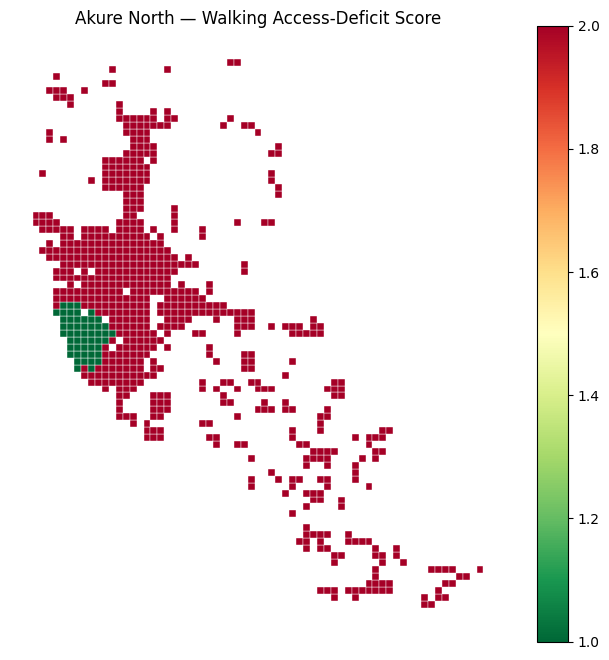

In [6]:
import matplotlib.pyplot as plt

lga_to_plot = "Akure North"
grid_to_plot = scored_results[lga_to_plot]

fig, ax = plt.subplots(figsize=(8, 8))
settled = grid_to_plot[grid_to_plot["building_count"] > 0]
settled.plot(
    ax=ax, column="walk_access_deficit_score", cmap="RdYlGn_r",
    legend=True, edgecolor="white", linewidth=0.3,
    missing_kwds={"color": "lightgrey"},
)
ax.set_title(f"{lga_to_plot} — Walking Access-Deficit Score")
ax.set_axis_off()
plt.show()


## 7. Export

**Outputs produced (per LGA):**

```
data/processed/{lga_name}/grid_access_scored.geojson
data/processed/{lga_name}/isochrones_health_walk.geojson
```

Each grid cell in `grid_access_scored.geojson` carries, per mode
(`walk` / `okada` / `drive`):
- `{service}_time_min_{mode}` — travel time in minutes
- `{service}_distance_km_{mode}` — network distance in km
- `{mode}_access_deficit_score` — composite 0–2 score

This file is what `dashboard/app.py` reads directly, and what Notebook 04
combines across both LGAs for the ranked underserved-settlement list.

`isochrones_health_walk.geojson` carries one row per (health facility,
trip time) combination, with columns `facility_name`, `osmid`,
`trip_time_min` (15/30/45), and a convex-hull reachable-area polygon.
`dashboard/app.py` loads this as an optional overlay -- see its own
docstring for how it handles this file being absent (e.g. for an LGA
where this notebook hasn't been re-run since this feature was added).

## 8. Summary

**What this notebook accomplished:** built routable road networks for
three transport modes, computed nearest-facility travel time to health
and education services for every settled grid cell in both LGAs, and
derived a composite access-deficit score per mode using a multi-source
Dijkstra approach for tractable runtime.

**Outputs produced:** see Section 7 above.

**Next notebook:** `04_results_summary.ipynb` combines both LGAs' scored
grids, produces the ranked underserved-settlement list, and exports
summary tables for the project report and StoryMap.